# DenseNet121 — Rahman

## 1. Load and check the shared dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/Deep Learning Project/processed/gtsrb_data.npz" /content/
import numpy as np
data = np.load("/content/gtsrb_data.npz")
for name in data.files:
    arr = data[name]
    print(name, arr.shape, arr.dtype, "min:", arr.min(), "max:", arr.max())

Mounted at /content/drive
X_train (33327, 64, 64, 3) float32 min: 0.0 max: 1.0
y_train (33327,) int64 min: 0 max: 42
X_val (5882, 64, 64, 3) float32 min: 0.0 max: 1.0
y_val (5882,) int64 min: 0 max: 42
X_test (12630, 64, 64, 3) float32 min: 0.0 max: 1.0
y_test (12630,) int64 min: 0 max: 42


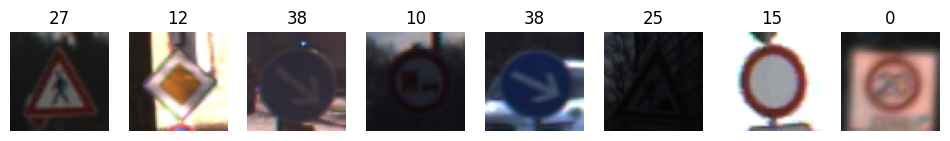

In [3]:
import matplotlib.pyplot as plt
X_train, y_train = data["X_train"], data["y_train"]

plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

## 2. Prepare the data for PyTorch

In [4]:
import torch
X_train_t = torch.from_numpy(X_train)
print(type(X_train_t))
print(X_train_t.shape)

<class 'torch.Tensor'>
torch.Size([33327, 64, 64, 3])


In [5]:
X_train_t = torch.from_numpy(X_train).permute(0, 3, 1, 2)
print(X_train_t.shape)

torch.Size([33327, 3, 64, 64])


In [6]:
X_val, y_val = data["X_val"], data["y_val"]

X_val_t   = torch.from_numpy(X_val).permute(0, 3, 1, 2)
y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)

print(X_val_t.shape, y_train_t.shape, y_val_t.shape)

torch.Size([5882, 3, 64, 64]) torch.Size([33327]) torch.Size([5882])


In [7]:
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print(len(train_loader))

1042


In [8]:
val_data = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
print(len(val_loader))

images, labels = next(iter(train_loader))
print(images.shape)
print(labels)

184
torch.Size([32, 3, 64, 64])
tensor([15, 13, 16, 17, 22, 38,  0,  3,  5,  7,  7,  2,  9, 13, 34,  1, 18, 10,
        31, 12, 25,  7,  2, 24, 37, 12,  2, 24, 18,  9,  9, 38])


In [9]:
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

print("before:", images.min().item(), images.max().item())
images_norm = normalize(images)
print("after:", images_norm.min().item(), images_norm.max().item())

before: 0.0 1.0
after: -2.1179039478302 2.640000104904175
